# Chapter 1 - Exploratory Data Analysis

**Book:** *Practical Statistics for Data Scientists* (Bruce, Bruce & Gedeck, O'Reilly)

## Chapter summary
Exploratory Data Analysis (EDA), pioneered by John Tukey, is the first step of any data project: **look at the data before modelling it**.
This chapter introduces:

1. **Elements of structured data** - numeric (continuous / discrete) and categorical (binary / ordinal) data, and the *rectangular data* (data frame) format.
2. **Estimates of location** - mean, trimmed mean, weighted mean, median, weighted median.
3. **Estimates of variability** - variance, standard deviation, mean absolute deviation, median absolute deviation (MAD), range, percentiles, IQR.
4. **Exploring the data distribution** - boxplots, frequency tables, histograms, density plots.
5. **Binary and categorical data** - mode, expected value, bar charts.
6. **Correlation** - correlation coefficient, correlation matrix, scatterplots.
7. **Exploring two or more variables** - hexagonal binning, contour plots, contingency tables, violin plots, conditional (faceted) plots.

The recurring theme is **robustness**: statistics like the mean and standard deviation are sensitive to outliers, while the median, trimmed mean and MAD are not.

In [28]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"

def get_data(name):
    """Download a dataset of the book (once) into ./data and return its path."""
    path = Path("data") / name
    path.parent.mkdir(exist_ok=True)
    if not path.exists():
        urllib.request.urlretrieve(DATA_URL + name, path)
    return path

sns.set_style("whitegrid")
pd.set_option("display.width", 120)

## 1. Estimates of Location

**Theory.** A *location estimate* answers "what is a typical value?".

* **Mean**: $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$. Simple but sensitive to extreme values.
* **Trimmed mean**: drop the $p$ smallest and $p$ largest values before averaging. A compromise between mean and median that resists outliers (used e.g. in Olympic judging).
* **Weighted mean**: $\bar{x}_w = \frac{\sum w_i x_i}{\sum w_i}$. Used when observations have different importance (e.g. a state's murder rate weighted by its population).
* **Median**: the middle value of the sorted data - a *robust* estimate. The **weighted median** is the value that splits the total weight in half.
* **Robust** means "not sensitive to extreme values (outliers)".

We use US state population and murder rate data.

In [29]:
state = pd.read_csv(get_data("state.csv"))
state.head(8)

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE


In [30]:
print("Mean           :", state["Population"].mean())
print("Trimmed mean   :", trim_mean(state["Population"], 0.1))   # drop 10% from each end
print("Median         :", state["Population"].median())

Mean           : 6162876.3
Trimmed mean   : 4783697.125
Median         : 4436369.5


The mean (6.2M) is pulled upward by a few very populous states; the median (4.4M) and trimmed mean are better "typical" values.

In [31]:
print("Mean murder rate (unweighted):", state["Murder.Rate"].mean())
print("Weighted mean (by population) :", np.average(state["Murder.Rate"], weights=state["Population"]))
print("Weighted median               :", wquantiles.median(state["Murder.Rate"], weights=state["Population"]))

Mean murder rate (unweighted): 4.066
Weighted mean (by population) : 4.445833981123393
Weighted median               : 4.4


## 2. Estimates of Variability (Dispersion)

**Theory.** Location is only one feature of a distribution; *variability* tells us whether values cluster tightly or spread widely.

* **Deviations** (errors, residuals): $x_i - \bar{x}$ - they sum to zero, so we need to square or take absolute values.
* **Mean absolute deviation**: $\frac{1}{n}\sum |x_i-\bar{x}|$
* **Variance**: $s^2 = \frac{\sum (x_i-\bar{x})^2}{n-1}$ - divided by $n-1$ ("degrees of freedom") so that the estimate is unbiased.
* **Standard deviation**: $s=\sqrt{s^2}$, in the same units as the data.
* **Median absolute deviation (MAD)**: $\text{median}(|x_i - m|)$, a robust alternative (scaled by 1.4826 to be comparable with the SD for normal data).
* **Range / percentiles / IQR**: the IQR is the 75th minus the 25th percentile and is robust.

In [32]:
print("Std. deviation :", state["Population"].std())
print("IQR            :", state["Population"].quantile(0.75) - state["Population"].quantile(0.25))
print("MAD            :", robust.scale.mad(state["Population"]))

Std. deviation : 6848235.347401142
IQR            : 4847308.0
MAD            : 3849876.1459979336


The standard deviation is much larger than the (robust) IQR/MAD because of the outlying large states.

## 3. Exploring the Data Distribution

**Theory.** Single-number summaries hide the *shape* of the data. Useful visual tools:

* **Percentiles / quantiles**: the value below which $P\%$ of the data fall.
* **Boxplot** (Tukey): box = 25th-75th percentile, line = median, whiskers extend to at most 1.5 x IQR, points beyond are flagged outliers.
* **Frequency table & histogram**: counts of values falling into equally spaced bins.
* **Density plot**: a smoothed histogram (kernel density estimate), with area equal to 1.

In [33]:
print(state["Murder.Rate"].quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64


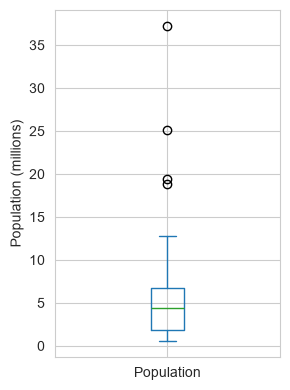

In [34]:
ax = (state["Population"] / 1_000_000).plot.box(figsize=(3, 4))
ax.set_ylabel("Population (millions)")
plt.tight_layout(); plt.show()

In [35]:
binned = pd.cut(state["Population"], 10)
print(binned.value_counts().sort_index())

Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
(33584923.0, 37253956.0]     1
Name: count, dtype: int64


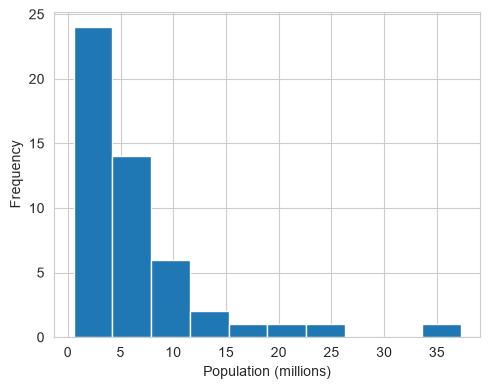

In [36]:
ax = (state["Population"] / 1_000_000).plot.hist(figsize=(5, 4), bins=10)
ax.set_xlabel("Population (millions)")
plt.tight_layout(); plt.show()

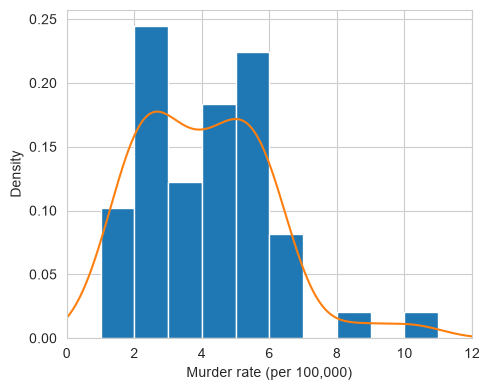

In [37]:
ax = state["Murder.Rate"].plot.hist(density=True, xlim=[0, 12], bins=range(1, 12), figsize=(5, 4))
state["Murder.Rate"].plot.density(ax=ax)
ax.set_xlabel("Murder rate (per 100,000)")
plt.tight_layout(); plt.show()

## 4. Exploring Binary and Categorical Data

**Theory.**
* **Mode**: the most frequent category.
* **Expected value**: for categories that can be mapped to numbers, the sum of each value times its probability, $E[X]=\sum x_i p_i$.
* **Bar charts** show counts or proportions per category (unlike histograms, bars are separated, since categories have no ordering/width).

Data: causes of airline delays at Dallas/Fort Worth airport.

In [38]:
dfw = pd.read_csv(get_data("dfw_airline.csv"))
dfw

,Carrier,ATC,Weather,Security,Inbound
0,64263.16,84856.5,11235.42,343.15,118427.82


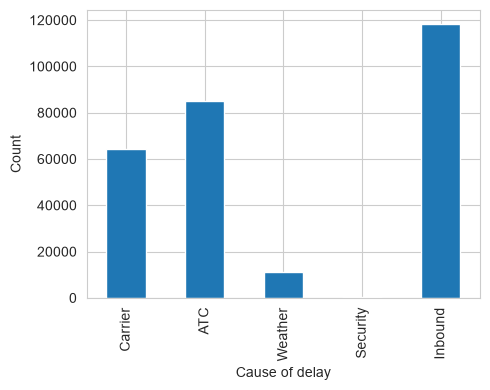

In [39]:
ax = dfw.transpose().plot.bar(figsize=(5, 4), legend=False)
ax.set_xlabel("Cause of delay"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

## 5. Correlation

**Theory.** The **Pearson correlation coefficient** measures linear association between two numeric variables:

$$ r = \frac{\sum_{i}(x_i-\bar{x})(y_i-\bar{y})}{(n-1)\,s_x s_y} $$

It lies between -1 (perfect negative) and +1 (perfect positive); 0 means no *linear* relationship. A **correlation matrix** tabulates $r$ for all pairs, and a **scatterplot** reveals non-linear patterns and outliers that $r$ alone hides. Pearson's $r$ is sensitive to outliers; rank-based (Spearman, Kendall) alternatives are robust.

We look at daily returns of telecom stocks and at ETFs.

In [40]:
sp500_px = pd.read_csv(get_data("sp500_data.csv.gz"), index_col=0)
sp500_sym = pd.read_csv(get_data("sp500_sectors.csv"))

telecom_symbols = sp500_sym[sp500_sym["sector"] == "telecommunications_services"]["symbol"]
telecom = sp500_px.loc[sp500_px.index >= "2012-07-01", telecom_symbols]
telecom.corr()

,T,CTL,FTR,VZ,LVLT
T,1.000000,0.474683,0.327767,0.677612,0.278626
CTL,0.474683,1.000000,0.419757,0.416604,0.286665
FTR,0.327767,0.419757,1.000000,0.287386,0.260068
VZ,0.677612,0.416604,0.287386,1.000000,0.242199
LVLT,0.278626,0.286665,0.260068,0.242199,1.000000


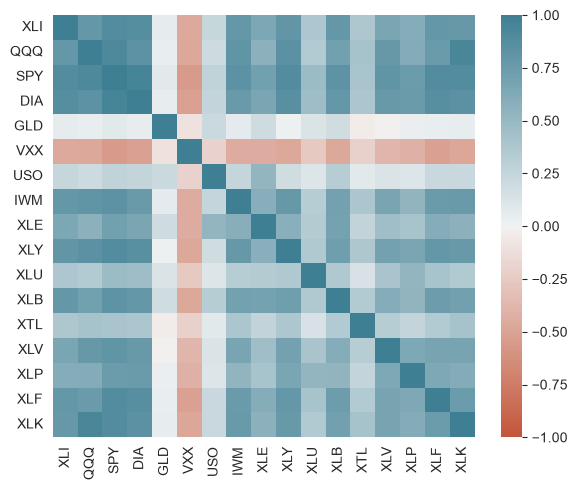

In [41]:
etfs = sp500_px.loc[sp500_px.index > "2012-07-01", sp500_sym[sp500_sym["sector"] == "etf"]["symbol"]]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(etfs.corr(), vmin=-1, vmax=1, cmap=sns.diverging_palette(20, 220, as_cmap=True), ax=ax)
plt.tight_layout(); plt.show()

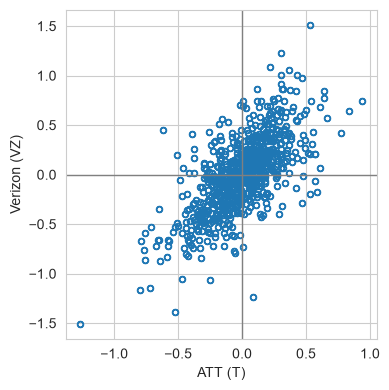

In [42]:
ax = telecom.plot.scatter(x="T", y="VZ", figsize=(4, 4), marker="$◯$")
ax.set_xlabel("ATT (T)"); ax.set_ylabel("Verizon (VZ)")
ax.axhline(0, color="grey", lw=1); ax.axvline(0, color="grey", lw=1)
plt.tight_layout(); plt.show()

## 6. Exploring Two or More Variables

**Theory.** Correlation and scatterplots work for two numeric variables with few points. With many records:

* **Hexagonal binning / contour plots** avoid overplotting by showing point density.
* **Contingency tables** count records in each combination of two categorical variables.
* **Boxplots and violin plots** compare a numeric variable across categories (the violin shows the full density shape).
* **Conditioning / faceting** (small multiples) shows relationships split by additional variables.

Data: King County (Seattle) tax-assessed home values.

In [43]:
kc_tax = pd.read_csv(get_data("kc_tax.csv.gz"))
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), :]
print(kc_tax0.shape)

(432693, 3)


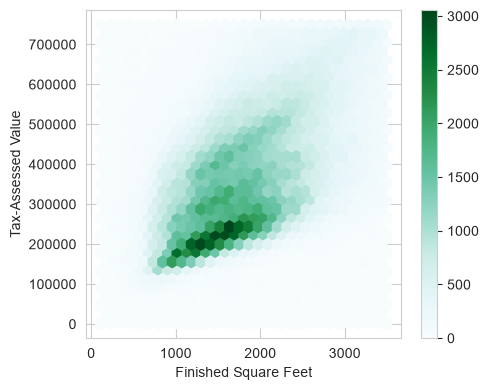

In [44]:
ax = kc_tax0.plot.hexbin(x="SqFtTotLiving", y="TaxAssessedValue", gridsize=30, sharex=False, figsize=(5, 4))
ax.set_xlabel("Finished Square Feet"); ax.set_ylabel("Tax-Assessed Value")
plt.tight_layout(); plt.show()

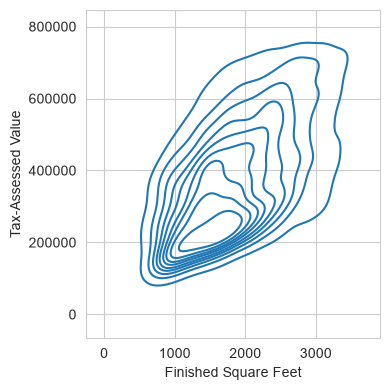

In [45]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.kdeplot(data=kc_tax0.sample(10000, random_state=1), x="SqFtTotLiving", y="TaxAssessedValue", ax=ax)
ax.set_xlabel("Finished Square Feet"); ax.set_ylabel("Tax-Assessed Value")
plt.tight_layout(); plt.show()

**Contingency table**: loan grade vs. loan status from Lending Club.

In [46]:
lc_loans = pd.read_csv(get_data("lc_loans.csv"))
crosstab = pd.crosstab(lc_loans["grade"], lc_loans["status"], margins=True)   # counts, with row/column totals
print(crosstab)

# row proportions: share of each status within every grade (the "All" column is the share of loans per grade)
df = crosstab.div(crosstab["All"], axis=0).drop(columns="All")
df["All"] = crosstab["All"] / crosstab.loc["All", "All"]
print(df.round(3))

status  Charged Off  Current  Fully Paid  Late     All
grade                                                 
A              1562    50051       20408   469   72490
B              5302    93852       31160  2056  132370
C              6023    88928       23147  2777  120875
D              5007    53281       13681  2308   74277
E              2842    24639        5949  1374   34804
F              1526     8444        2328   606   12904
G               409     1990         643   199    3241
All           22671   321185       97316  9789  450961
status  Charged Off  Current  Fully Paid   Late    All
grade                                                 
A             0.022    0.690       0.282  0.006  0.161
B             0.040    0.709       0.235  0.016  0.294
C             0.050    0.736       0.191  0.023  0.268
D             0.067    0.717       0.184  0.031  0.165
E             0.082    0.708       0.171  0.039  0.077
F             0.118    0.654       0.180  0.047  0.029
G         

**Categorical vs. numeric**: airline delay percentages with boxplots and a violin plot.

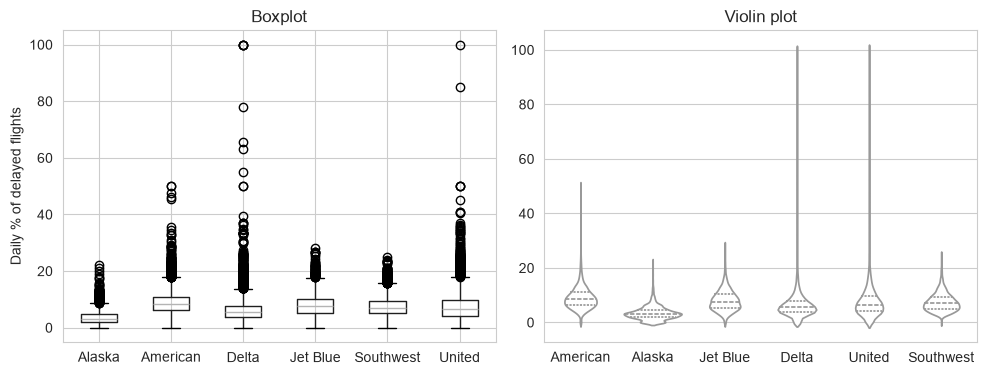

In [47]:
airline_stats = pd.read_csv(get_data("airline_stats.csv"))
fig, axes = plt.subplots(ncols=2, figsize=(10, 4))
airline_stats.boxplot(by="airline", column="pct_carrier_delay", ax=axes[0])
axes[0].set_xlabel(""); axes[0].set_ylabel("Daily % of delayed flights"); axes[0].set_title("Boxplot")
sns.violinplot(data=airline_stats, x="airline", y="pct_carrier_delay", inner="quartile", color="white", ax=axes[1])
axes[1].set_xlabel(""); axes[1].set_ylabel(""); axes[1].set_title("Violin plot")
plt.suptitle(""); plt.tight_layout(); plt.show()

**Conditioning**: relationship between size and value, split by zip code.

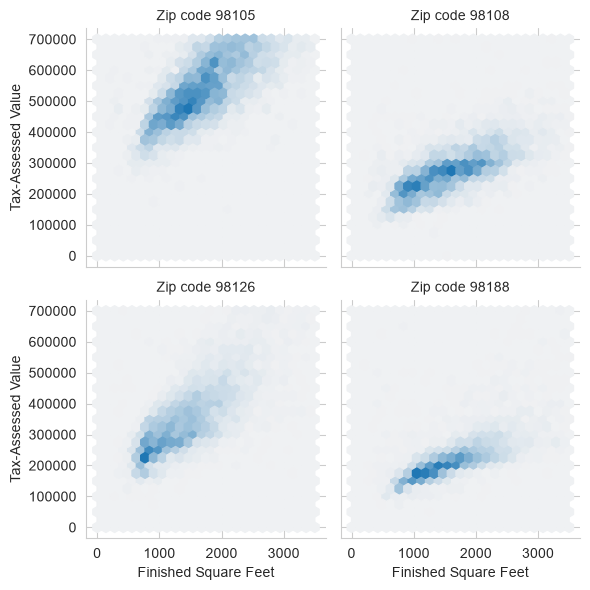

In [48]:
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes), :]

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col="ZipCode", col_wrap=2)
g.map(hexbin, "SqFtTotLiving", "TaxAssessedValue", extent=[0, 3500, 0, 700000])
g.set_axis_labels("Finished Square Feet", "Tax-Assessed Value")
g.set_titles("Zip code {col_name:.0f}")
plt.tight_layout(); plt.show()

## Key takeaways
* Always plot and summarise data before modelling; use *robust* estimates (median, trimmed mean, MAD, IQR) when outliers are possible.
* Histograms/boxplots/density plots reveal skewness and outliers; bar charts and contingency tables summarise categorical data.
* Correlation measures *linear* association only - inspect scatterplots too; use hexbin/contour plots for large data and facets to condition on a third variable.